In [11]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from nnsight import LanguageModel, util

def _find_delimiter_token_index(tokenizer, text, delimiter=","):
    """Tokenizer-agnostic delimiter lookup using character offsets."""
    char_idx = text.find(delimiter)
    if char_idx == -1:
        raise ValueError(f"Delimiter '{delimiter}' not found in text.")

    encoded = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=True,
    )
    offsets = encoded.get("offset_mapping")
    if offsets is None:
        raise ValueError("Tokenizer did not return offset mapping.")

    for tok_idx, (start, end) in enumerate(offsets):
        # Skip special tokens that often map to (0, 0)
        if start == end:
            continue
        if start <= char_idx < end:
            return tok_idx

    raise ValueError(f"Could not map delimiter '{delimiter}' to token index.")


In [13]:

import json
import numpy as np
import torch

path = "attention_accum_gpt2_new_dataset1_v2.npz"
data = np.load(path)

acc = torch.from_numpy(data["accumulated_results"]).float()   # shape: [layers, heads]
n = int(data["total_combinations"])

avg = acc / n
n_layers, n_heads = avg.shape
def top_heads(k):
    vals, idxs = torch.topk(avg.flatten(), k)
    out = []
    for i in idxs.tolist():
        layer = i // n_heads
        head = i % n_heads
        out.append([layer, head])  # save as [layer, head]
    return out

for k in [14, 36]:
    out = top_heads(k)
    with open(f"top_{k}_heads_gpt2_from_accumulator.json", "w") as f:
        json.dump(out, f, indent=2)
    print(f"\nTop {k} heads:")
    print(out)


Top 14 heads:
[[0, 0], [0, 7], [0, 2], [4, 1], [6, 5], [9, 3], [6, 6], [10, 10], [9, 11], [1, 8], [8, 6], [1, 11], [9, 4], [3, 7]]

Top 36 heads:
[[0, 0], [0, 7], [0, 2], [4, 1], [6, 5], [9, 3], [6, 6], [10, 10], [9, 11], [1, 8], [8, 6], [1, 11], [9, 4], [3, 7], [0, 9], [5, 1], [4, 7], [11, 8], [3, 0], [7, 9], [0, 8], [3, 9], [4, 4], [3, 11], [7, 8], [8, 9], [8, 2], [3, 10], [0, 6], [10, 4], [9, 5], [6, 1], [5, 3], [11, 2], [6, 7], [9, 8]]


In [9]:
path = "residual_stream_accum_new_dataset1_v2.npz"
# load the npz file
data = np.load(path)
# print the keys
print(data.keys())
total_results = data["total_results"]
counts = data["counts"]


KeysView(NpzFile 'residual_stream_accum_new_dataset1_v2.npz' with keys: total_results, counts)


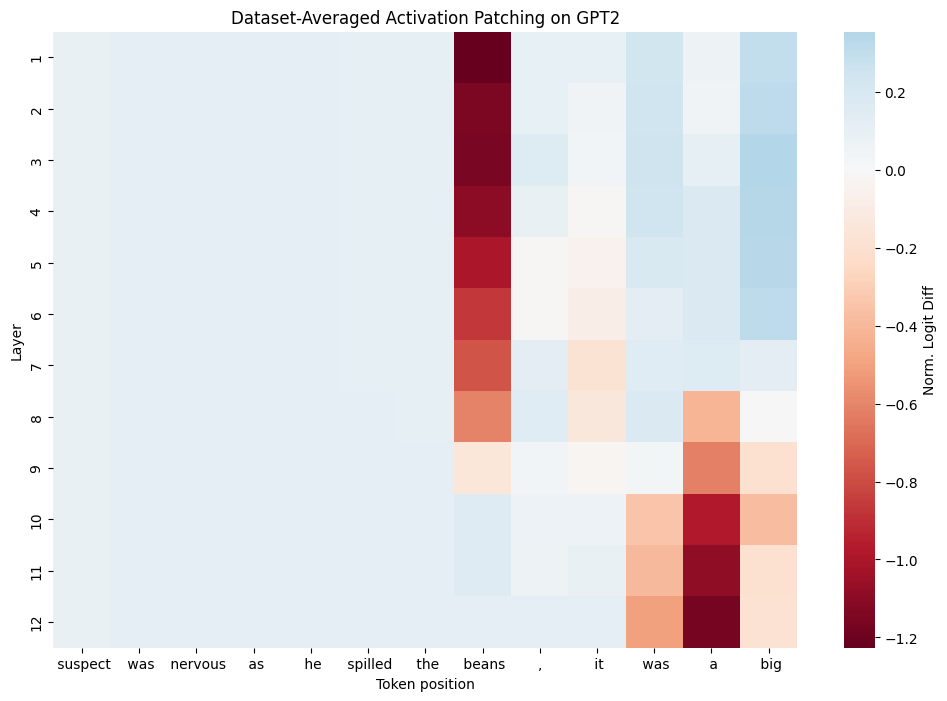

In [10]:


model = LanguageModel("openai-community/gpt2")
N_LAYERS = 12
avg_results = np.divide(total_results, counts, out=np.zeros_like(total_results), where=counts!=0)
# Use first idiom's first pair for labels
prompt_idiom = "The suspect was nervous as he spilled the beans, it was a big"
        
idiom_tokens = model.tokenizer(prompt_idiom, return_tensors="pt")["input_ids"][0]
try:
    and_token_idx = _find_delimiter_token_index(model.tokenizer, prompt_idiom, delimiter=",")
    
except ValueError:
    print("Error finding delimiter token index")


label_start = max(0, and_token_idx - 8)
label_end = min(len(idiom_tokens), and_token_idx + 5)
labels = [model.tokenizer.decode(token) for token in idiom_tokens[label_start:label_end]]
# Calculate the absolute maximum to make the scale symmetric
y_labels = list(range(1, N_LAYERS + 1))
plt.figure(figsize=(12, 8))
sns.heatmap(
            avg_results,
            xticklabels=labels,
            yticklabels=y_labels,
            cmap="RdBu",
            cbar_kws={'label': 'Norm. Logit Diff'},
            center=0
        )
plt.xlabel("Token position")
plt.ylabel("Layer")
plt.title(f"Dataset-Averaged Activation Patching on GPT2")
# plt.savefig(f"averaged_patching_results_mistral7b.png")
# plt.savefig(f"averaged_patching_results_mistral7b.eps")
plt.gca() # Often helpful to have Layer 0 at the bottom
plt.show()